# ShopKart: What's driving growth, and where are we leaking revenue?

**Role:** Data Analyst · **Tools:** Python (pandas, matplotlib, SciPy), SQL (SQLite) · **Data:** Jan 2024 – Dec 2025

ShopKart is a (fictional) Indian e-commerce marketplace. Leadership asked four questions ahead of FY27 planning:

1. **Growth** — How fast are we growing, and how dependent are we on the Diwali season?
2. **Profitability** — Which categories make money after returns and cost of goods?
3. **Customers** — Which acquisition channels bring customers who come back?
4. **Leakage** — Where do we lose orders (cancellations, returns, funnel), and should we ship the new checkout?

> Data is synthetic but realistic (generated by `data/generate_data.py`); the raw exports contain the kinds of
> quality problems found in real source systems. All numbers below are computed live in this notebook.

In [1]:
import sys, sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats

PROJECT = Path.cwd()
ROOT = PROJECT.parents[1]
sys.path.insert(0, str(PROJECT / "src"))
from cleaning import run as run_cleaning

FIG = PROJECT / "figures"; FIG.mkdir(exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "axes.titlesize": 12, "font.size": 10})
BLUE, ORANGE, GREY, RED, GREEN = "#1F77B4", "#FF7F0E", "#9E9E9E", "#D62728", "#2CA02C"
inr = mtick.FuncFormatter(lambda x, _: f"₹{x/1e5:,.0f}L" if abs(x) >= 1e5 else f"₹{x:,.0f}")

def save(fig, name):
    fig.tight_layout(); fig.savefig(FIG / f"{name}.png", bbox_inches="tight", dpi=150)

## 1. Data cleaning & quality report

The source exports (`data/raw/`) were cleaned with a logged, repeatable pipeline (`src/cleaning.py`).
Every issue found, and the decision taken, is listed below.

In [2]:
data, quality = run_cleaning()
customers, orders, items, products = data["customers"], data["orders"], data["items"], data["products"]
quality

,table,issue,rows_affected,action
0,customers,Exact duplicate rows,160,Dropped
1,customers,"Near-duplicates (same customer_id, stray white...",80,"Trimmed, kept first"
2,customers,"City spelling / casing variants (Bangalore, NE...",1160,Standardised to official names
3,customers,"signup_date in mixed formats (dd/mm/yyyy, dd M...",2365,Parsed all 3 formats
4,customers,Upper-case emails,786,Lower-cased
5,customers,Missing email,231,Kept (not needed for analysis)
6,customers,Missing acquisition_channel,184,Labelled 'Unknown'
7,orders,Exact duplicate rows,119,Dropped
8,orders,"Status casing / trailing spaces ('delivered ',...",2954,Trimmed + Title Case
9,orders,"Payment method variants (COD, upi, CC…)",2300,Mapped to 5 canonical values


In [3]:
# Build one analysis table at order-line level
VALID = ["Delivered", "Shipped"]
lines = (items.merge(orders, on="order_id")
              .merge(products[["product_id", "product_name", "category", "unit_cost"]], on="product_id")
              .merge(customers[["customer_id", "city", "state", "region", "acquisition_channel"]], on="customer_id"))
lines["net_revenue"] = lines["quantity"] * lines["unit_price"] - lines["discount"]
lines["cogs"] = lines["quantity"] * lines["unit_cost"]
lines["month"] = lines["order_ts"].dt.to_period("M")
valid = lines[lines["status"].isin(VALID)]

# Order-level table
order_val = (lines.groupby("order_id")
                  .agg(customer_id=("customer_id", "first"), order_ts=("order_ts", "first"), status=("status", "first"),
                       device=("device", "first"), payment_method=("payment_method", "first"),
                       coupon_code=("coupon_code", "first"), state=("state", "first"), value=("net_revenue", "sum"))
                  .reset_index())
print(f"{len(customers):,} customers · {len(orders):,} orders · {len(items):,} order lines · {len(products)} products")

8,000 customers · 11,885 orders · 20,298 order lines · 48 products


## 2. Growth: headline KPIs

In [4]:
def kpis(df_lines, df_orders):
    v = df_lines[df_lines["status"].isin(VALID)]
    vo = df_orders[df_orders["status"].isin(VALID)]
    return pd.Series({
        "Net revenue (₹)": v["net_revenue"].sum(),
        "Valid orders": vo["order_id"].nunique(),
        "AOV (₹)": v["net_revenue"].sum() / vo["order_id"].nunique(),
        "Buying customers": vo["customer_id"].nunique(),
        "Gross margin %": 100 * (v["net_revenue"].sum() - v["cogs"].sum()) / v["net_revenue"].sum(),
        "Cancel rate %": 100 * (df_orders["status"] == "Cancelled").mean(),
        "Return rate %": 100 * (df_orders["status"] == "Returned").mean(),
    })

yr_l, yr_o = lines["order_ts"].dt.year, order_val["order_ts"].dt.year
kpi = pd.DataFrame({y: kpis(lines[yr_l == y], order_val[yr_o == y]) for y in (2024, 2025)})
kpi["YoY change"] = np.where(kpi.index.str.contains("%"), kpi[2025] - kpi[2024], 100 * (kpi[2025] / kpi[2024] - 1))
kpi["YoY change"] = [f"{v:+.1f} pp" if "%" in i else f"{v:+.1f}%" for i, v in kpi["YoY change"].items()]
kpi

,2024,2025,YoY change
Net revenue (₹),"10,571,565.65","19,961,219.65",+88.8%
Valid orders,"3,584.00","6,541.00",+82.5%
AOV (₹),"2,949.66","3,051.71",+3.5%
Buying customers,"2,252.00","4,033.00",+79.1%
Gross margin %,34.37,37.46,+3.1 pp
Cancel rate %,5.52,5.56,+0.0 pp
Return rate %,8.88,9.47,+0.6 pp


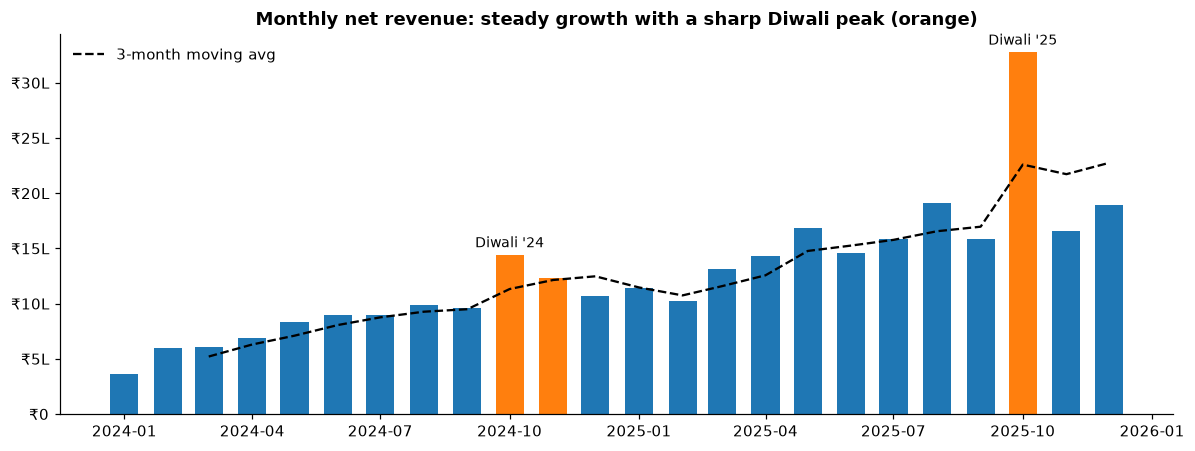

2024: Oct–Nov = 25.3% of annual revenue (2 of 12 months = 16.7%); peak month = 1.5x the Jul–Sep monthly average
2025: Oct–Nov = 24.7% of annual revenue (2 of 12 months = 16.7%); peak month = 1.9x the Jul–Sep monthly average


In [5]:
monthly = valid.groupby("month").agg(revenue=("net_revenue", "sum"), orders=("order_id", "nunique"))
monthly.index = monthly.index.to_timestamp()
festive_share, peak_ratio = {}, {}
for y in (2024, 2025):
    m = monthly[monthly.index.year == y]
    festive_share[y] = 100 * m[m.index.month.isin([10, 11])]["revenue"].sum() / m["revenue"].sum()
    peak_ratio[y] = m["revenue"].max() / m[m.index.month.isin([7, 8, 9])]["revenue"].mean()

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(monthly.index, monthly["revenue"], width=20, color=[ORANGE if d.month in (10, 11) and not (d.year == 2025 and d.month == 11) else BLUE for d in monthly.index])
ax.plot(monthly.index, monthly["revenue"].rolling(3).mean(), color="black", lw=1.5, ls="--", label="3-month moving avg")
ax.yaxis.set_major_formatter(inr)
ax.set_title("Monthly net revenue: steady growth with a sharp Diwali peak (orange)")
for d, lab in [(pd.Timestamp("2024-10-01"), "Diwali '24"), (pd.Timestamp("2025-10-01"), "Diwali '25")]:
    ax.annotate(lab, (d, monthly.loc[d, "revenue"]), textcoords="offset points", xytext=(0, 5), ha="center", fontsize=9)
ax.legend(frameon=False); save(fig, "01_monthly_revenue")
plt.show()
for y in (2024, 2025):
    print(f"{y}: Oct–Nov = {festive_share[y]:.1f}% of annual revenue (2 of 12 months = 16.7%); "
          f"peak month = {peak_ratio[y]:.1f}x the Jul–Sep monthly average")

In [6]:
# Strip out the festive season: is the underlying business still growing?
non_fest = monthly[~monthly.index.month.isin([10, 11])]
h1 = {y: non_fest[(non_fest.index.year == y) & (non_fest.index.month <= 6)]["revenue"].sum() for y in (2024, 2025)}
print(f"Jan–Jun revenue: 2024 ₹{h1[2024]:,.0f} → 2025 ₹{h1[2025]:,.0f} ({100*(h1[2025]/h1[2024]-1):+.0f}% YoY)")

Jan–Jun revenue: 2024 ₹3,981,561 → 2025 ₹8,051,041 (+102% YoY)


## 3. Profitability by category: revenue ≠ profit

In [7]:
cat = lines[lines["status"].isin(VALID + ["Returned"])].copy()
by_cat = (cat.groupby("category")
             .apply(lambda g: pd.Series({
                 "net_revenue": g.loc[g.status.isin(VALID), "net_revenue"].sum(),
                 "gross_profit": (g.loc[g.status.isin(VALID), "net_revenue"] - g.loc[g.status.isin(VALID), "cogs"]).sum(),
                 "return_rate_%": 100 * (g["status"] == "Returned").mean(),
                 "returned_value": g.loc[g.status == "Returned", "net_revenue"].sum(),
             }), include_groups=False)
             .sort_values("net_revenue", ascending=False))
by_cat["margin_%"] = 100 * by_cat["gross_profit"] / by_cat["net_revenue"]
by_cat["revenue_share_%"] = 100 * by_cat["net_revenue"] / by_cat["net_revenue"].sum()
by_cat["profit_share_%"] = 100 * by_cat["gross_profit"] / by_cat["gross_profit"].sum()
by_cat[["net_revenue", "revenue_share_%", "gross_profit", "profit_share_%", "margin_%", "return_rate_%", "returned_value"]]

,net_revenue,revenue_share_%,gross_profit,profit_share_%,margin_%,return_rate_%,returned_value
category,,,,,,,
Electronics,"10,740,264.90",35.18,"2,156,505.65",19.41,20.08,9.22,"1,084,872.05"
Fashion,"9,676,192.05",31.69,"5,108,537.94",45.98,52.79,15.82,"1,797,342.15"
Home & Kitchen,"5,313,842.90",17.40,"1,743,417.50",15.69,32.81,8.65,"474,911.65"
Sports,"2,206,985.40",7.23,"843,101.61",7.59,38.20,10.10,"231,774.70"
Beauty,"1,939,916.25",6.35,"1,076,269.43",9.69,55.48,7.72,"157,711.30"
Books,"655,583.80",2.15,"182,873.70",1.65,27.89,7.37,"53,888.60"


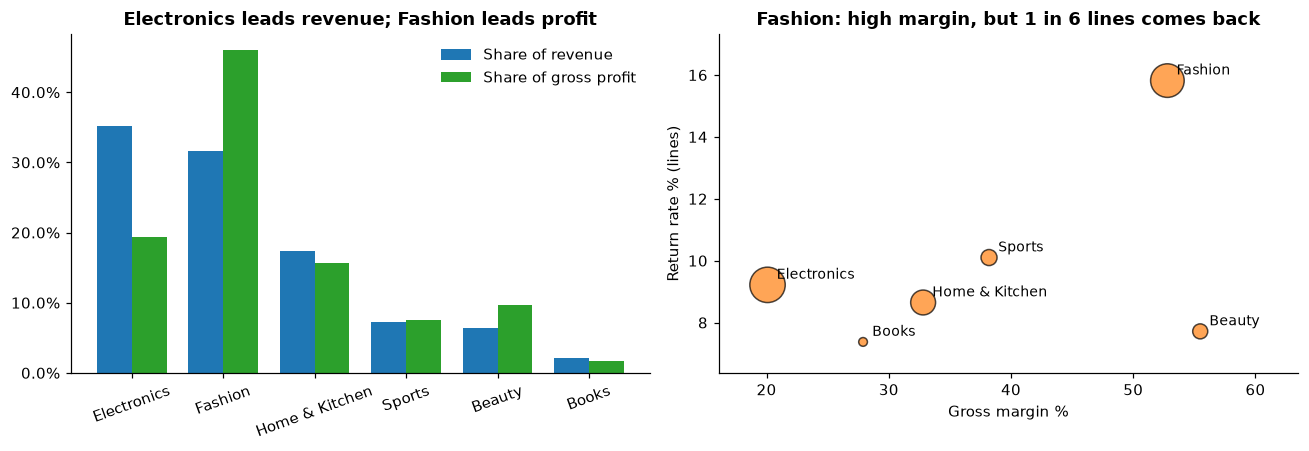

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
x = np.arange(len(by_cat)); w = 0.38
axes[0].bar(x - w/2, by_cat["revenue_share_%"], w, label="Share of revenue", color=BLUE)
axes[0].bar(x + w/2, by_cat["profit_share_%"], w, label="Share of gross profit", color=GREEN)
axes[0].set_xticks(x, by_cat.index, rotation=20); axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_title("Electronics leads revenue; Fashion leads profit"); axes[0].legend(frameon=False)

axes[1].scatter(by_cat["margin_%"], by_cat["return_rate_%"], s=by_cat["net_revenue"] / 2e4, color=ORANGE, alpha=.7, edgecolor="k")
for name, r in by_cat.iterrows():
    axes[1].annotate(name, (r["margin_%"], r["return_rate_%"]), textcoords="offset points", xytext=(6, 4), fontsize=9)
axes[1].set_ylim(by_cat["return_rate_%"].min() - 1, by_cat["return_rate_%"].max() + 1.5)
axes[1].set_xlim(by_cat["margin_%"].min() - 4, by_cat["margin_%"].max() + 8)
axes[1].set_xlabel("Gross margin %"); axes[1].set_ylabel("Return rate % (lines)")
axes[1].set_title("Fashion: high margin, but 1 in 6 lines comes back")
save(fig, "02_category_profitability"); plt.show()

## 4. Customers: which channels bring customers who come back?

In [9]:
cust_rev = valid.groupby("customer_id")["net_revenue"].sum()
n_orders = orders.groupby("customer_id").size()
c = customers[["customer_id", "acquisition_channel"]].copy()
c["revenue"] = c["customer_id"].map(cust_rev).fillna(0)
c["orders"] = c["customer_id"].map(n_orders).fillna(0)
channel = (c[c["acquisition_channel"] != "Unknown"].groupby("acquisition_channel")
            .agg(customers=("customer_id", "count"),
                 buyer_pct=("orders", lambda s: 100 * (s > 0).mean()),
                 repeat_pct_of_buyers=("orders", lambda s: 100 * (s >= 2).sum() / (s > 0).sum()),
                 revenue_per_customer=("revenue", "mean"))
            .sort_values("revenue_per_customer", ascending=False))
channel

,customers,buyer_pct,repeat_pct_of_buyers,revenue_per_customer
acquisition_channel,,,,
Referral,975,88.62,64.47,"6,009.38"
Email,637,85.09,58.49,"4,971.65"
Organic Search,2180,80.87,51.90,"4,307.07"
Paid Search,1492,80.09,42.01,"3,373.10"
Affiliate,651,71.12,34.56,"2,656.27"
Paid Social,1881,66.99,34.37,"2,520.34"


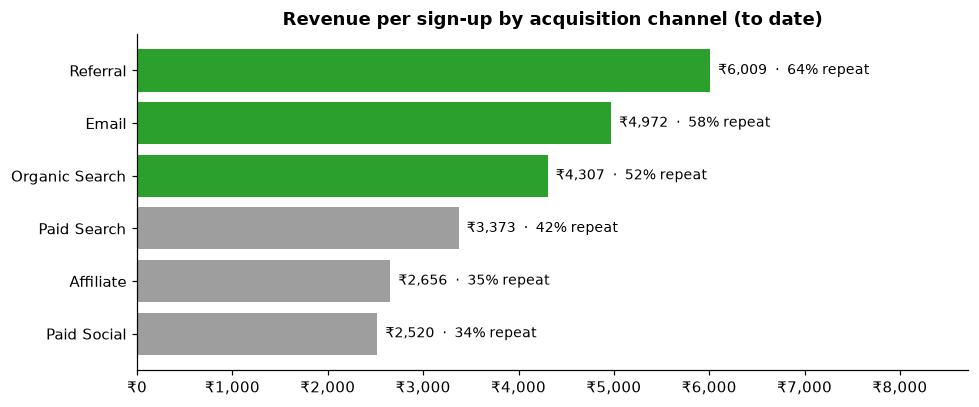

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.8))
colors = [GREEN if v >= channel["revenue_per_customer"].median() else GREY for v in channel["revenue_per_customer"]]
ax.barh(channel.index[::-1], channel["revenue_per_customer"][::-1], color=colors[::-1])
for i, (v, rp) in enumerate(zip(channel["revenue_per_customer"][::-1], channel["repeat_pct_of_buyers"][::-1])):
    ax.text(v, i, f"  ₹{v:,.0f}  ·  {rp:.0f}% repeat", va="center", fontsize=9)
ax.set_xlim(0, channel["revenue_per_customer"].max() * 1.45); ax.xaxis.set_major_formatter(inr)
ax.set_title("Revenue per sign-up by acquisition channel (to date)")
save(fig, "03_channel_value"); plt.show()

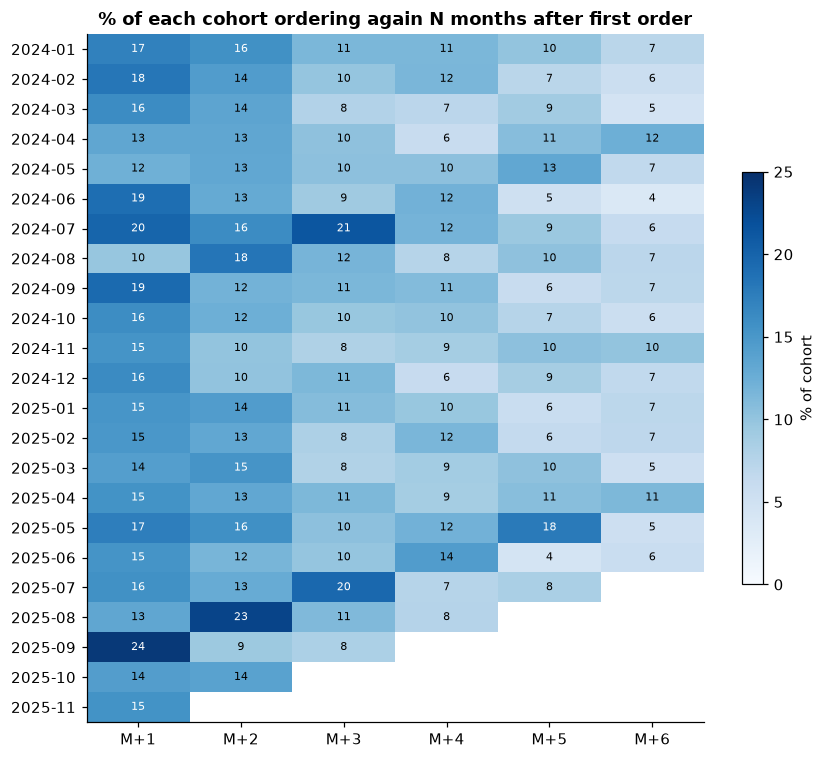

Average M+1 retention: 16.0% · M+3: 11.0% · M+6: 6.9%


In [11]:
# Monthly cohort retention (cohort = month of first order)
o = orders[["customer_id", "order_ts"]].copy()
o["order_month"] = o["order_ts"].dt.to_period("M")
o["cohort"] = o.groupby("customer_id")["order_month"].transform("min")
o["age"] = (o["order_month"] - o["cohort"]).apply(lambda d: d.n)
cohort = o[o["age"] <= 6].groupby(["cohort", "age"])["customer_id"].nunique().unstack()
retention = cohort.div(cohort[0], axis=0) * 100
# hide cells that are in the future (not yet observable)
last = o["order_month"].max()
for coh in retention.index:
    for age in retention.columns:
        if coh + age > last:
            retention.loc[coh, age] = np.nan
retention = retention[retention[1].notna()]          # drop cohorts with nothing observable yet
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(retention.iloc[:, 1:], cmap="Blues", aspect="auto", vmin=0, vmax=25)
ax.set_xticks(range(6), [f"M+{i}" for i in range(1, 7)]); ax.set_yticks(range(len(retention)), retention.index.astype(str))
for (i, j), v in np.ndenumerate(retention.iloc[:, 1:].values):
    if not np.isnan(v): ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7, color="white" if v > 15 else "black")
ax.set_title("% of each cohort ordering again N months after first order")
fig.colorbar(im, ax=ax, shrink=.6, label="% of cohort"); save(fig, "04_cohort_retention"); plt.show()
print(f"Average M+1 retention: {retention[1].mean():.1f}% · M+3: {retention[3].mean():.1f}% · M+6: {retention[6].mean():.1f}%")

## 5. Leakage: cancellations, an operational incident, and the funnel

In [12]:
pay = (order_val.groupby("payment_method")
         .agg(orders=("order_id", "count"), cancel_rate=("status", lambda s: 100 * (s == "Cancelled").mean()))
         .sort_values("cancel_rate", ascending=False))
prepaid_rate = order_val.loc[order_val.payment_method != "Cash on Delivery", "status"].eq("Cancelled").mean()
cod = order_val[order_val.payment_method == "Cash on Delivery"]
excess_cancels = cod["status"].eq("Cancelled").sum() - prepaid_rate * len(cod)
excess_value = excess_cancels * cod.loc[cod.status != "Cancelled", "value"].mean()
print(f"COD cancel rate {pay.loc['Cash on Delivery','cancel_rate']:.1f}% vs {100*prepaid_rate:.1f}% for prepaid → "
      f"~{excess_cancels:,.0f} excess cancelled orders ≈ ₹{excess_value:,.0f} of GMV over two years")
pay

COD cancel rate 11.7% vs 4.0% for prepaid → ~179 excess cancelled orders ≈ ₹529,881 of GMV over two years


,orders,cancel_rate
payment_method,,
Cash on Delivery,2332,11.71
Debit Card,1239,4.92
Net Banking,720,4.31
UPI,5498,3.95
Credit Card,2096,3.67


n  cancel
state       month               
Maharashtra 2025-06  111   30.63
West Bengal 2025-03   32   12.50
            2025-07   34   11.76

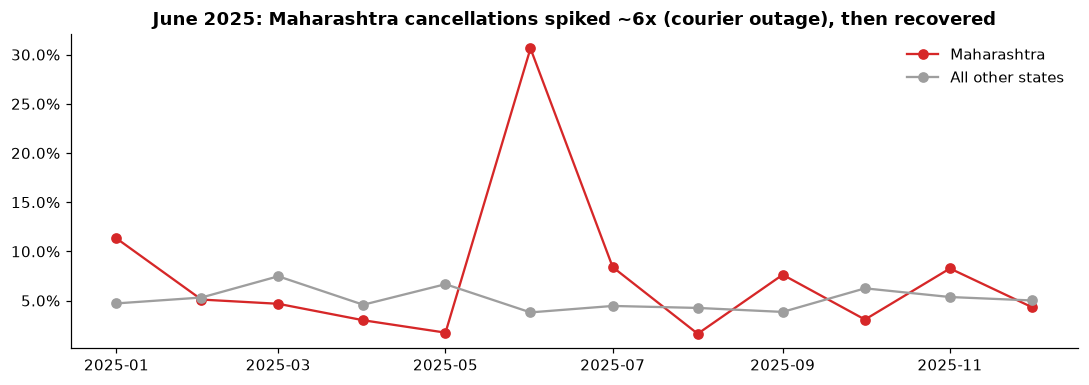

In [13]:
# Hunting the anomaly: cancellation rate by state and month (2025)
o25 = order_val[order_val["order_ts"].dt.year == 2025].copy()
o25["month"] = o25["order_ts"].dt.to_period("M")
sm = o25.groupby(["state", "month"]).agg(n=("order_id", "count"), cancel=("status", lambda s: 100 * (s == "Cancelled").mean()))
top = sm[sm["n"] >= 30].sort_values("cancel", ascending=False).head(3)
display(top)
mh = sm.loc["Maharashtra"]["cancel"]; rest = o25[o25.state != "Maharashtra"].groupby("month")["status"].apply(lambda s: 100 * (s == "Cancelled").mean())
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(mh.index.to_timestamp(), mh.values, marker="o", color=RED, label="Maharashtra")
ax.plot(rest.index.to_timestamp(), rest.values, marker="o", color=GREY, label="All other states")
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.legend(frameon=False)
ax.set_title("June 2025: Maharashtra cancellations spiked ~6x (courier outage), then recovered")
save(fig, "05_incident"); plt.show()

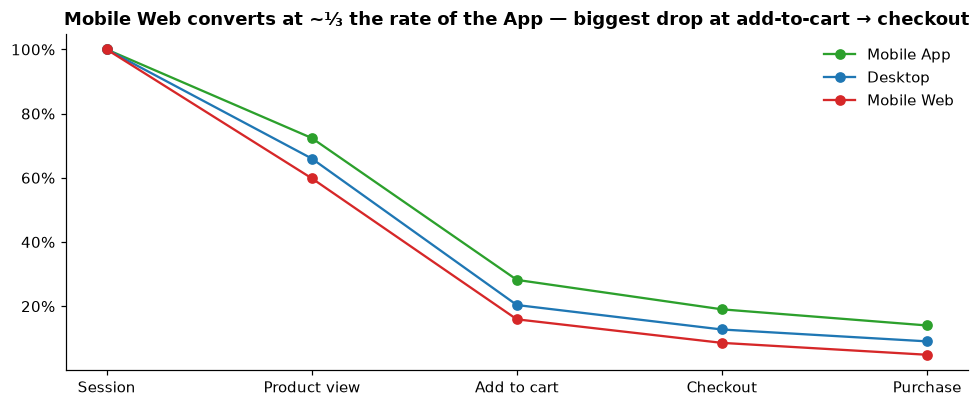

,viewed_product,added_to_cart,began_checkout,purchased,cart→checkout %
device,,,,,
Desktop,66.00,20.40,12.70,9.00,62.60
Mobile App,72.40,28.20,19.00,14.00,67.50
Mobile Web,59.80,15.90,8.60,4.90,53.90


In [14]:
sessions = pd.read_csv(ROOT / "data" / "clean" / "web_sessions.csv")
steps = ["viewed_product", "added_to_cart", "began_checkout", "purchased"]
funnel = sessions.groupby("device")[steps].mean().mul(100)
funnel.insert(0, "sessions", sessions.groupby("device").size())
fig, ax = plt.subplots(figsize=(9, 3.8))
for dev, col in zip(["Mobile App", "Desktop", "Mobile Web"], [GREEN, BLUE, RED]):
    ax.plot(["Session", "Product view", "Add to cart", "Checkout", "Purchase"], [100] + list(funnel.loc[dev, steps]),
            marker="o", label=dev, color=col)
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.legend(frameon=False)
ax.set_title("Mobile Web converts at ~⅓ the rate of the App — biggest drop at add-to-cart → checkout")
save(fig, "06_funnel"); plt.show()
step_conv = funnel[steps].copy()
step_conv["cart→checkout %"] = 100 * funnel["began_checkout"] / funnel["added_to_cart"]
step_conv.round(1)

## 6. Experiment readout: new checkout (1–28 Sep 2025)

**Hypothesis:** the redesigned checkout increases visitor→order conversion.
**Primary metric:** conversion rate. **Guardrail:** revenue per visitor. **Test:** two-sided two-proportion z-test, α = 0.05.

In [15]:
exp = pd.read_csv(ROOT / "data" / "clean" / "checkout_experiment.csv")

def ztest(df):
    g = df.groupby("variant")["converted"].agg(["sum", "count"])
    (xa, na), (xb, nb) = g.loc["A_control"], g.loc["B_new_checkout"]
    pa, pb = xa / na, xb / nb
    pp = (xa + xb) / (na + nb)
    z = (pb - pa) / np.sqrt(pp * (1 - pp) * (1 / na + 1 / nb))
    se = np.sqrt(pa * (1 - pa) / na + pb * (1 - pb) / nb)
    return pd.Series({"n_A": na, "n_B": nb, "conv_A_%": 100 * pa, "conv_B_%": 100 * pb, "lift_pp": 100 * (pb - pa),
                      "rel_lift_%": 100 * (pb / pa - 1), "ci95_low_pp": 100 * (pb - pa - 1.96 * se),
                      "ci95_high_pp": 100 * (pb - pa + 1.96 * se), "p_value": 2 * stats.norm.sf(abs(z))})

# Sanity check first: sample ratio mismatch (should be ~50/50)
counts = exp["variant"].value_counts()
srm_p = stats.chisquare(counts).pvalue
print(f"Split: {counts.to_dict()} · SRM chi-square p = {srm_p:.2f} (no mismatch if > 0.01)")

overall = ztest(exp).to_frame("Overall").T
by_device = exp.groupby("device").apply(ztest, include_groups=False)
readout = pd.concat([overall, by_device])
rpv = exp.groupby("variant")["order_value"].mean()
t_rpv = stats.ttest_ind(exp.loc[exp.variant == "B_new_checkout", "order_value"], exp.loc[exp.variant == "A_control", "order_value"], equal_var=False)
print(f"Guardrail — revenue/visitor: A ₹{rpv['A_control']:.2f} vs B ₹{rpv['B_new_checkout']:.2f} (Welch p = {t_rpv.pvalue:.3f})")
readout.style.format({"n_A": "{:,.0f}", "n_B": "{:,.0f}", "p_value": "{:.4f}"}, precision=2)

Split: {'A_control': 12006, 'B_new_checkout': 11994} · SRM chi-square p = 0.94 (no mismatch if > 0.01)
Guardrail — revenue/visitor: A ₹149.13 vs B ₹164.08 (Welch p = 0.027)


,n_A,n_B,conv_A_%,conv_B_%,lift_pp,rel_lift_%,ci95_low_pp,ci95_high_pp,p_value
Overall,"12,006","11,994",10.34,11.79,1.44,13.96,0.65,2.24,0.0004
Desktop,"2,347","2,335",10.74,10.32,-0.42,-3.87,-2.17,1.34,0.6429
Mobile App,"5,379","5,465",11.34,14.57,3.23,28.44,1.96,4.49,0.0000
Mobile Web,"4,280","4,194",8.88,8.99,0.11,1.24,-1.10,1.33,0.8584


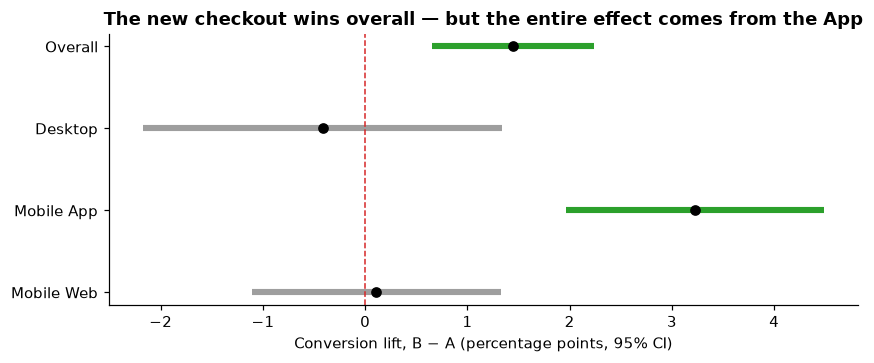

In [16]:
fig, ax = plt.subplots(figsize=(8, 3.4))
r = readout.iloc[::-1]
ax.errorbar(r["lift_pp"], range(len(r)), xerr=[r["lift_pp"] - r["ci95_low_pp"], r["ci95_high_pp"] - r["lift_pp"]],
            fmt="o", color="black", ecolor=[GREEN if lo > 0 else GREY for lo in r["ci95_low_pp"]], elinewidth=4, capsize=0)
ax.axvline(0, color=RED, lw=1, ls="--"); ax.set_yticks(range(len(r)), r.index)
ax.set_xlabel("Conversion lift, B − A (percentage points, 95% CI)")
ax.set_title("The new checkout wins overall — but the entire effect comes from the App")
save(fig, "07_ab_test"); plt.show()

*Caution on segments:* device was not a pre-registered split, so the per-device result is a **hypothesis**, not a
conclusion — it needs a follow-up test. The overall result (the pre-registered primary metric) is what justifies shipping.

## 7. Sizing the opportunities

In [17]:
annual_2025 = kpi.loc["Net revenue (₹)", 2025]
aov_2025 = kpi.loc["AOV (₹)", 2025]

# 1) Checkout B on the App: incremental conversion x app share of orders
app_lift = readout.loc["Mobile App", "lift_pp"] / readout.loc["Mobile App", "conv_A_%"]
app_rev_share = valid[valid.order_ts.dt.year == 2025].groupby("device")["net_revenue"].sum()
app_rev_share = app_rev_share["Mobile App"] / app_rev_share.sum()
opp_checkout = annual_2025 * app_rev_share * app_lift * 0.5   # 50% haircut for novelty effect / regression to the mean

# 2) COD: halve the excess cancellations (e.g. prepaid nudges, OTP confirmation for COD)
opp_cod = excess_value / 2 / 2        # per year (2-year figure / 2), halved

# 3) Fashion returns: cut the return rate by 3 points (size guides, fit reviews)
fashion = lines[(lines.category == "Fashion") & (lines.order_ts.dt.year == 2025)]
opp_returns = 0.03 * fashion.loc[fashion.status.isin(VALID + ["Returned"]), "net_revenue"].sum()

sizing = pd.DataFrame({
    "Opportunity": ["Ship new checkout on App", "Reduce COD cancellations by half", "Cut Fashion returns by 3 pp"],
    "Est. annual revenue (₹)": [opp_checkout, opp_cod, opp_returns],
})
sizing["% of 2025 revenue"] = 100 * sizing["Est. annual revenue (₹)"] / annual_2025
sizing

,Opportunity,Est. annual revenue (₹),% of 2025 revenue
0,Ship new checkout on App,"1,435,321.02",7.19
1,Reduce COD cancellations by half,"132,470.34",0.66
2,Cut Fashion returns by 3 pp,"227,497.65",1.14


## 8. Recommendations

| # | Recommendation | Evidence | Next step |
|---|---|---|---|
| 1 | **Ship the new checkout to the Mobile App now**; hold on Web/Desktop | Significant overall lift; App-only effect | Follow-up test on Mobile Web with the App design adapted |
| 2 | **Shift COD customers to prepaid** (UPI cashback, COD confirmation OTP) | COD cancels ~3x more than prepaid | A/B test a ₹25 UPI incentive at checkout |
| 3 | **Rebalance acquisition budget toward Referral & Email** | Highest revenue per sign-up and repeat rate; Paid Social lowest | Compute CAC by channel with Marketing (spend data needed) |
| 4 | **Attack Fashion returns** (size charts, fit feedback, try-on) | 16% return rate on the highest-margin category | Tag return reasons at source |
| 5 | **Carrier SLA monitoring by state** | Maharashtra June spike went unnoticed for a month | Daily alert: state cancel rate > 2x baseline |
| 6 | **Plan inventory & staffing for Diwali** | Festive month ≈ 2x a normal month | Forecast Oct 2026 with seasonality model |

### Limitations
* No marketing spend → can't compute CAC/ROI by channel; "value per sign-up" is revenue, not profit.
* Web sessions and experiment visitors aren't linked to orders, so funnel and A/B results are analysed separately.
* 2025 cohorts have short observation windows; recent retention figures will move.